<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS05/JS05_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05_01 — kNN pada Iris

# Nama: Joni Yoga Kusuma
#NIM: 254107023003
# Kelas: TI-3F

## Persiapan

Jika library belum terpasang, hapus `#` pada baris `%pip` lalu jalankan.

In [1]:
# %pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 25)
pd.set_option('display.precision', 4)

### Lokasi data

Ubah `DATA_DIR` jika CSV disimpan di folder lain.

In [3]:
DATA_DIR = Path('.')

def data_path(nama):
    kandidat = [
        DATA_DIR / nama, DATA_DIR / 'data' / nama,
        Path('/content') / nama, Path.home() / 'Downloads' / nama
    ]
    for lokasi in kandidat:
        if lokasi.is_file():
            return lokasi
    raise FileNotFoundError(
        f'{nama} tidak ditemukan. Letakkan CSV di folder notebook/data/ '
        'atau ubah DATA_DIR.'
    )

for nama in ['iris.csv']:
    lokasi = data_path(nama)
    print(f'{nama}: ditemukan ({lokasi.stat().st_size:,} byte)')

def evaluasi_model(model, X_train, X_test, y_train, y_test, nama, labels=None):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    hasil = {
        'Model': nama,
        'Akurasi train': accuracy_score(y_train, pred_train),
        'Akurasi test': accuracy_score(y_test, pred_test),
        'F1 makro': f1_score(y_test, pred_test, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_test, pred_test),
    }
    display(pd.DataFrame([hasil]).set_index('Model'))
    print(classification_report(y_test, pred_test, labels=labels, zero_division=0))
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_test, labels=labels, cmap='Blues', colorbar=False, ax=ax
    )
    ax.set(title=nama, xlabel='Prediksi', ylabel='Label sebenarnya')
    plt.tight_layout()
    plt.show()
    return hasil

iris.csv: ditemukan (3,878 byte)


## Membaca data

Menggunakan kNN untuk mengelompokkan bunga berdasarkan empat ukuran bunga.

In [4]:
iris = pd.read_csv(data_path('iris.csv'))
assert 'species' in iris.columns
assert not iris.isna().any().any(), 'Periksa nilai kosong sebelum melanjutkan.'
display(iris.head())
iris.info()
display(iris.describe())
display(iris['species'].value_counts().rename('Jumlah').to_frame())
print('Jumlah baris duplikat:', iris.duplicated().sum())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0573,3.7580,1.1993
std,0.8281,0.4359,1.7653,0.7622
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


,Jumlah
species,
setosa,50
versicolor,50
virginica,50


Jumlah baris duplikat: 1


### Melihat hubungan fitur

Grafik menunjukkan sebaran fitur tiap spesies. Semua 150 baris tetap dipakai seperti pada modul.

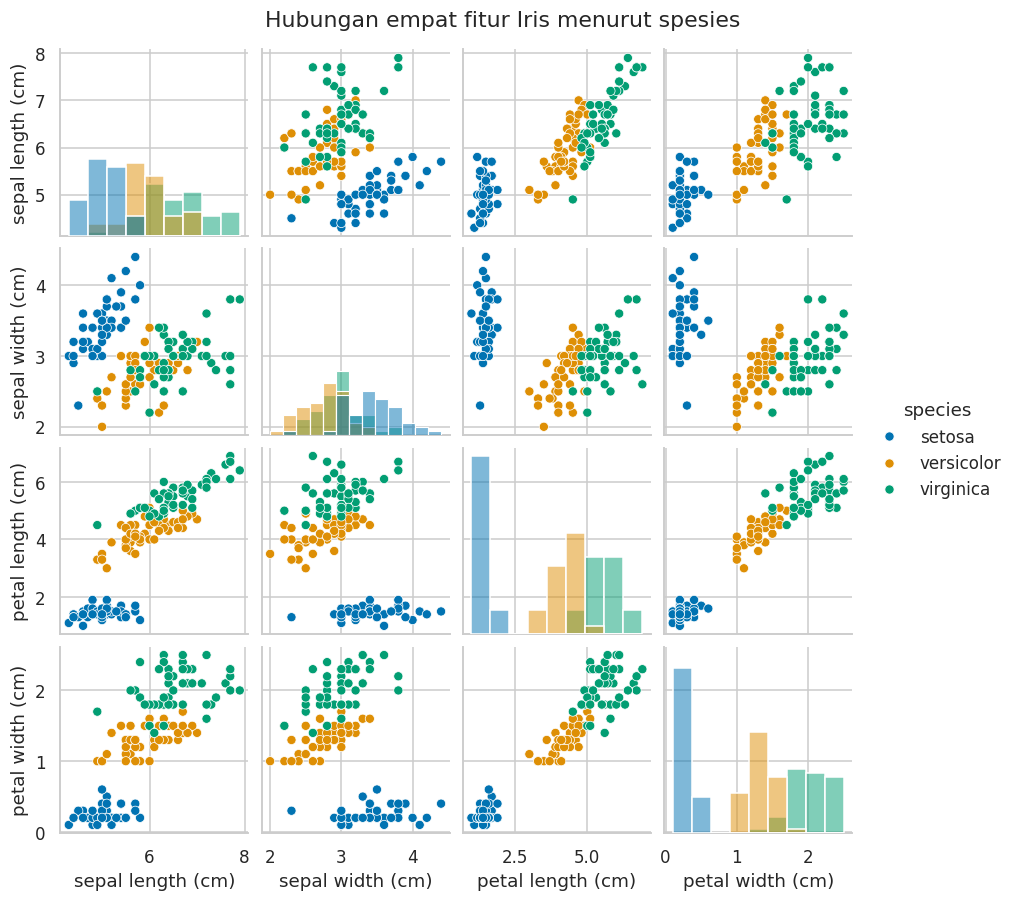

In [5]:
iris_plot = sns.pairplot(iris, hue='species', diag_kind='hist', height=2.0)
iris_plot.fig.suptitle('Hubungan empat fitur Iris menurut spesies', y=1.02)
plt.show()

### Membuat model

Data dibagi 70% latih dan 30% uji. Fitur distandardisasi dari data latih, lalu model dibuat dengan k = 3.

Train: 105 | Test: 45


,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
"Iris — kNN, k=3",0.9429,1.0,1.0,1.0


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



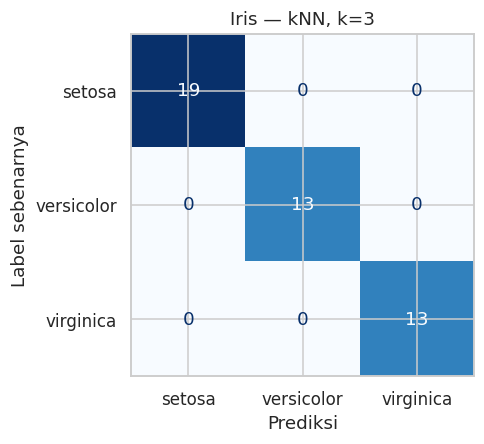

In [6]:
iris_X = iris.drop(columns='species')
iris_y = iris['species']
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X, iris_y, test_size=0.30, random_state=42
)
print(f'Train: {len(iris_X_train)} | Test: {len(iris_X_test)}')
iris_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])
iris_model.fit(iris_X_train, iris_y_train)
iris_hasil = evaluasi_model(
    iris_model, iris_X_train, iris_X_test, iris_y_train, iris_y_test,
    'Iris — kNN, k=3', labels=['setosa', 'versicolor', 'virginica']
)

### Mencoba k = 1–10

Grafik ini mengikuti contoh modul. Skor uji hanya untuk perbandingan, bukan untuk memilih k.

,k,Train,Test eksploratif
0,1,1.0000,0.9778
1,2,0.9619,0.9778
2,3,0.9429,1.0000
3,4,0.9524,0.9778
4,5,0.9524,1.0000
5,6,0.9524,1.0000
6,7,0.9429,1.0000
7,8,0.9429,1.0000
8,9,0.9429,1.0000
9,10,0.9333,1.0000


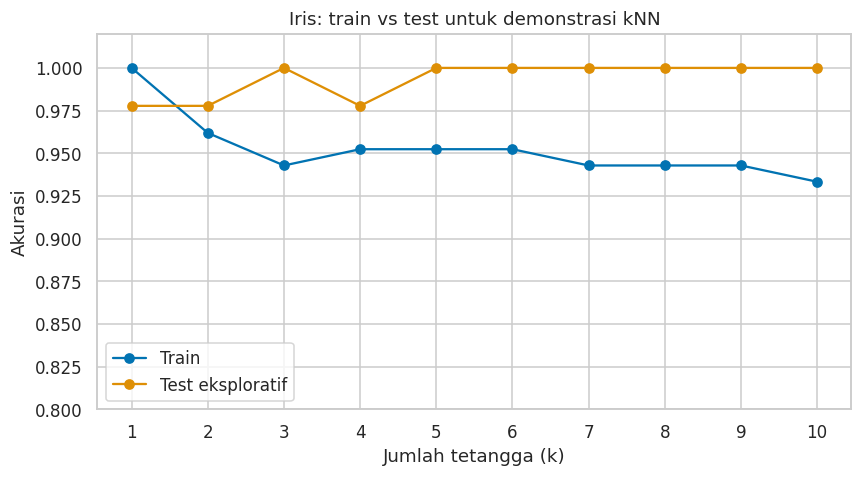

In [7]:
iris_k_rows = []
for iris_k in range(1, 11):
    iris_k_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=iris_k))
    ])
    iris_k_model.fit(iris_X_train, iris_y_train)
    iris_k_rows.append({
        'k': iris_k,
        'Train': iris_k_model.score(iris_X_train, iris_y_train),
        'Test eksploratif': iris_k_model.score(iris_X_test, iris_y_test)
    })
iris_k_result = pd.DataFrame(iris_k_rows)
display(iris_k_result)
iris_k_result.set_index('k').plot(marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Jumlah tetangga (k)')
plt.ylabel('Akurasi')
plt.title('Iris: train vs test untuk demonstrasi kNN')
plt.ylim(0.80, 1.02)
plt.tight_layout()
plt.show()

### Memilih k dengan validasi silang

Nilai k dipilih dari rata-rata akurasi 5-fold pada data latih. Jika skornya sama, dipilih k yang lebih besar.

,k,Train CV,Validasi CV,Simpangan CV
0,1,1.0000,0.9143,0.0356
1,2,0.9524,0.9143,0.0356
2,3,0.9500,0.9238,0.0381
3,4,0.9476,0.9429,0.0190
4,5,0.9548,0.9333,0.0233
5,6,0.9476,0.9429,0.0190
6,7,0.9381,0.9048,0.0602
7,8,0.9357,0.9238,0.0381
8,9,0.9429,0.9238,0.0381
9,10,0.9357,0.9333,0.0381


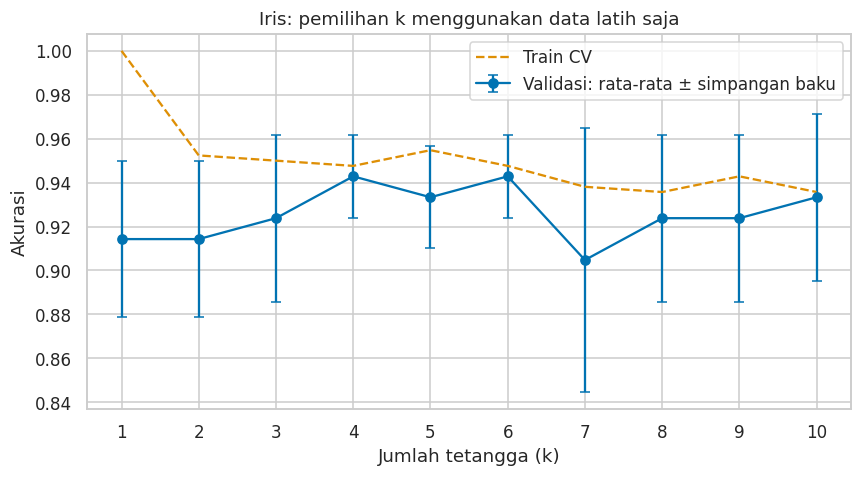

**Kesimpulan:** k = 3 mendapat akurasi uji 100.00%. Dari validasi silang, k terpilih adalah 6 dengan rata-rata akurasi 94.29%.

In [8]:
iris_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
iris_cv_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    {'knn__n_neighbors': list(range(1, 11))},
    cv=iris_cv, scoring='accuracy', return_train_score=True, n_jobs=1,
    refit=False
)
iris_cv_search.fit(iris_X_train, iris_y_train)
iris_cv_raw = pd.DataFrame(iris_cv_search.cv_results_)
iris_cv_result = pd.DataFrame({
    'k': iris_cv_raw['param_knn__n_neighbors'].astype(int),
    'Train CV': iris_cv_raw['mean_train_score'],
    'Validasi CV': iris_cv_raw['mean_test_score'],
    'Simpangan CV': iris_cv_raw['std_test_score']
})
iris_best = iris_cv_result.sort_values(
    ['Validasi CV', 'k'], ascending=[False, False]
).iloc[0]
display(iris_cv_result)
plt.errorbar(iris_cv_result['k'], iris_cv_result['Validasi CV'],
             yerr=iris_cv_result['Simpangan CV'], marker='o', capsize=3,
             label='Validasi: rata-rata ± simpangan baku')
plt.plot(iris_cv_result['k'], iris_cv_result['Train CV'], '--', label='Train CV')
plt.xticks(range(1, 11))
plt.xlabel('Jumlah tetangga (k)')
plt.ylabel('Akurasi')
plt.title('Iris: pemilihan k menggunakan data latih saja')
plt.legend()
plt.tight_layout()
plt.show()
display(Markdown(
    f"**Kesimpulan:** k = 3 mendapat akurasi uji {iris_hasil['Akurasi test']:.2%}. "
    f"Dari validasi silang, k terpilih adalah {int(iris_best['k'])} "
    f"dengan rata-rata akurasi {iris_best['Validasi CV']:.2%}."
))